# 第3章 k近邻算法

## 习题1
在 KNN 算法中，我们将训练集上的平方误差和作为选择 ***K*** 的标准，是否正确？  
&emsp; A. 错误  
&emsp; B. 正确 

**解答**

&emsp;&emsp;**答案：A**  
&emsp;&emsp;在KNN算法中，不能使用训练集上的平方误差和作为选择 ***K*** 值的标准。因为训练误差（如K=1时误差可能为0）仅反映模型对已知数据的拟合程度，而非对未知数据的泛化能力，若直接依赖训练误差会导致过拟合（如选择K=1时模型完全记忆训练样本），使模型在测试集上表现差。  
&emsp;&emsp;正确方法应通过验证集或交叉验证评估不同K值的预测误差，从而选择泛化性能最优的K值，确保模型对新数据的适应性。因此，选 **A. 错误**。

## 习题2
关于 KNN 算法描述错误的是：  
&emsp;A. KNN 算法用于分类和回归问题。  
&emsp;B. KNN 算法在空间中找到个最接近的样本进行预测。  
&emsp;C. KNN 算法的是经过学习得到的。 

**解答**

&emsp;&emsp;**答案：C**  
&emsp;&emsp;A.正确。KNN 算法既可用于分类（通过多数投票法预测类别标签），也可用于回归（通过K个邻居的平均值或加权平均值预测连续值）例如，在分类任务中，当K=3时，算法会找到最近的3个样本，根据它们的类别标签进行投票；在回归任务中，则计算这3个样本的目标值均值作为预测结果。  
&emsp;&emsp;B.正确。KNN的核心思想是基于距离度量（如欧氏距离、曼哈顿距离）在特征空间中找到与目标样本最近的K个训练样本，然后根据这些邻居的信息进行预测。例如，若K=5，算法会计算所有训练样本与目标样本的距离，选择最近的5个点，并基于它们的标签或数值进行推断。  
&emsp;&emsp;C.错误。KNN中的超参数 K 并非通过模型训练过程学习得到，而是需人工预先设定或通过交叉验证/网格搜索选择最优值。例如，用户需要在训练前尝试不同的K值（如1,3,5），并在验证集上评估性能（如分类准确率或回归均方误差），最终选择表现最佳的K值。这与线性回归中的权重参数（通过梯度下降学习得到）有本质区别。

## 习题3
本节的 KNN 算法中，我们采用了最常用的欧氏距离作为寻找邻居的标准。在哪些场景下，我们可能会用到其他距离度量，例如曼哈顿距离（Manhattan distance）？把第 3 节实验中的距离改为曼哈顿距离，观察对分类效果的影响。

**解答**

&emsp;&emsp;在机器学习中，曼哈顿距离（Manhattan distance）与欧几里得距离（Euclidean distance）是最常用的两种距离度量。它们的核心区别在于计算方式：曼哈顿距离是各维度绝对差之和，而欧几里得距离是各维度差值的平方和的平方根。  
&emsp;&emsp;欧式距离的计算公式为：   $$ c= \sqrt{(x_1 - x_2)^2 + (y_1 - y_2)^2} $$
&emsp;&emsp;曼哈顿距离的计算公式为：   $$ c= |x_1 - x_2| + |y_1 - y_2| $$
&emsp;&emsp;两种距离度量使用场景对比：  
|距离类型|使用场景|优势|劣势|
|:---:|:---:|:---:|:---:|
|曼哈顿距离|高维稀疏数据、网格路径、异常检测|对稀疏数据鲁棒、计算高效、符合网格逻辑|可能忽略多维综合关系|
|欧几里得距离|低维连续数据、物理空间测量|低维连续数据、物理空间测量|低维连续数据、物理空间测量|

&emsp;&emsp;将第 3 节实验中的距离改为曼哈顿距离，并进行观察：

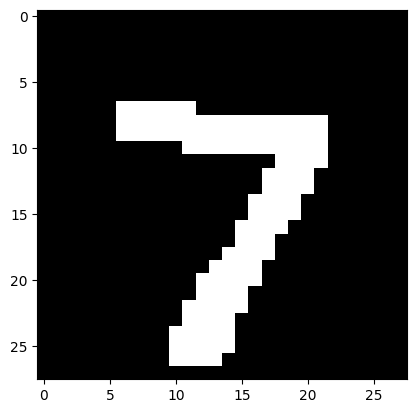

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os

# 读入mnist数据集
m_x = np.loadtxt('mnist_x', delimiter=' ')
m_y = np.loadtxt('mnist_y')

# 数据集可视化
data = np.reshape(np.array(m_x[0], dtype=int), [28, 28])
plt.figure()
plt.imshow(data, cmap='gray')

# 将数据集分为训练集和测试集
ratio = 0.8
split = int(len(m_x) * ratio)
# 打乱数据
np.random.seed(0)
idx = np.random.permutation(np.arange(len(m_x)))
m_x = m_x[idx]
m_y = m_y[idx]
x_train, x_test = m_x[:split], m_x[split:]
y_train, y_test = m_y[:split], m_y[split:]

In [2]:
#曼哈顿距离
def distance(a, b):
    return sum(abs(a - b))

In [3]:
class KNN:
    def __init__(self, k, label_num):
        self.k = k
        self.label_num = label_num # 类别的数量

    def fit(self, x_train, y_train):
        # 在类中保存训练数据
        self.x_train = x_train
        self.y_train = y_train

    def get_knn_indices(self, x):
        # 获取距离目标样本点最近的K个样本点的标签
        # 计算已知样本的距离
        dis = list(map(lambda a: distance(a, x), self.x_train))
        # 按距离从小到大排序，并得到对应的下标
        knn_indices = np.argsort(dis)
        # 取最近的K个
        knn_indices = knn_indices[:self.k]
        return knn_indices

    def get_label(self, x):
        # 对KNN方法的具体实现，观察K个近邻并使用np.argmax获取其中数量最多的类别
        knn_indices = self.get_knn_indices(x)
        # 类别计数
        label_statistic = np.zeros(shape=[self.label_num])
        for index in knn_indices:
            label = int(self.y_train[index])
            label_statistic[label] += 1
        # 返回数量最多的类别
        return np.argmax(label_statistic)

    def predict(self, x_test):
        # 预测样本 test_x 的类别
        predicted_test_labels = np.zeros(shape=[len(x_test)], dtype=int)
        for i, x in enumerate(x_test):
            predicted_test_labels[i] = self.get_label(x)
        return predicted_test_labels

In [4]:
for k in range(1, 10):
    knn = KNN(k, label_num=10)
    knn.fit(x_train, y_train)
    predicted_labels = knn.predict(x_test)

    accuracy = np.mean(predicted_labels == y_test)
    print(f'K的取值为 {k}, 预测准确率为 {accuracy * 100:.1f}%')

K的取值为 1, 预测准确率为 88.0%
K的取值为 2, 预测准确率为 88.0%
K的取值为 3, 预测准确率为 88.0%
K的取值为 4, 预测准确率为 87.0%
K的取值为 5, 预测准确率为 88.5%
K的取值为 6, 预测准确率为 88.5%
K的取值为 7, 预测准确率为 88.0%
K的取值为 8, 预测准确率为 87.5%
K的取值为 9, 预测准确率为 87.0%


##  习题4
在色彩风格迁移中，如果扩大采样的窗口，可能会产生什么问题？调整窗口大小并观察结果。

**解答**

&emsp;&emsp;如果扩大采样窗口可能导致以下问题：  
&emsp;&emsp;1. 计算效率显著下降  
&emsp;&emsp;&emsp;窗口扩大后，每个像素或图像块需处理的数据量成倍增加，导致计算时间大幅上升，尤其在高分辨率图像中可能变得难以实时处理。  
&emsp;&emsp;2. 局部细节模糊化  
&emsp;&emsp;&emsp;大窗口覆盖更多区域，促使颜色特征趋向平均化，导致迁移结果丢失纹理细节，图像整体呈现过度平滑的“油画感”。  
&emsp;&emsp;3. 风格与内容错位  
&emsp;&emsp;&emsp;窗口过大会引入无关区域的风格信息，造成色彩分布不协调，出现色块错位或边界渗透现象。  
&emsp;&emsp;4. 边缘过渡生硬  
&emsp;&emsp;&emsp;在物体边缘或颜色突变区域，大窗口无法精准捕捉局部变化规律，导致边缘处色彩混合不自然，形成锯齿状或突兀的色带。  
&emsp;&emsp;5. 内存占用激增  
&emsp;&emsp;&emsp;大规模窗口需存储更多邻域特征向量，可能超出GPU/内存容量限制，引发系统崩溃或运行卡顿。  

&emsp;&emsp;以窗口大小block_size = 2 为例：

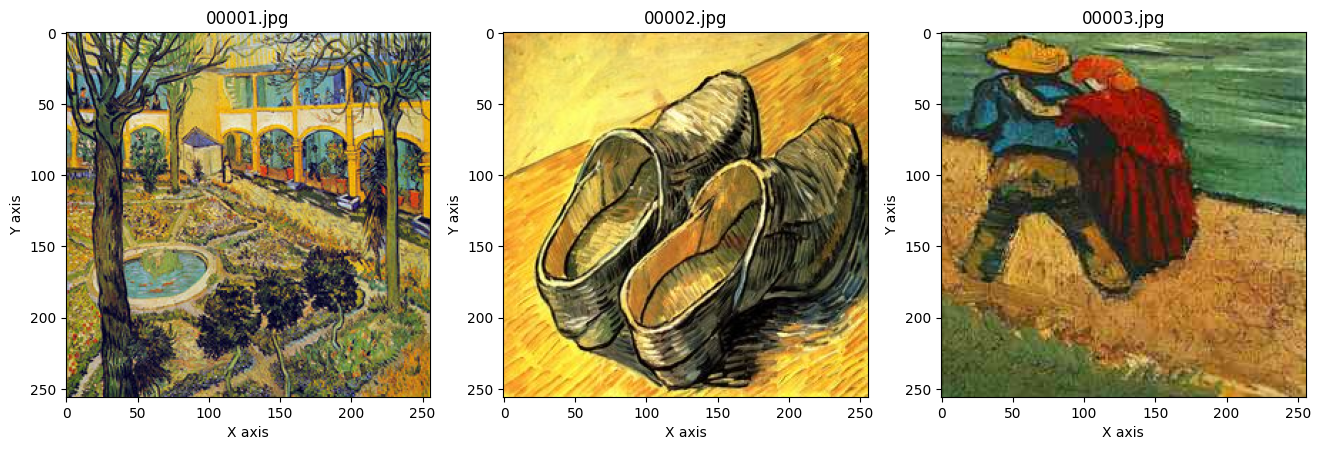

In [5]:
from skimage import io  # 图像输入输出
from skimage.color import rgb2lab, lab2rgb # 图像通道转换
from sklearn.neighbors import KNeighborsRegressor # KNN 回归器
import matplotlib.pyplot as plt
import numpy as np
import os

path = 'images'

data_dir = os.path.join(path, 'vangogh')
fig = plt.figure(figsize=(16, 5))
for i, file in enumerate(np.sort(os.listdir(data_dir))[:3]):
    img = io.imread(os.path.join(data_dir, file))
    ax = fig.add_subplot(1, 3, i + 1)
    ax.imshow(img)
    ax.set_xlabel('X axis')
    ax.set_ylabel('Y axis')
    ax.set_title(file)
plt.show()

In [6]:
# block_size表示向外扩展的层数，扩展1层即3*3
block_size = 2

def read_style_image(file_name, size=block_size):
    # 读入风格图像, 得到映射 X->Y
    # 其中X储存3*3像素格的灰度值，Y储存中心像素格的色彩值
    # 读取图像文件，设图像宽为W，高为H，得到W*H*3的RGB矩阵
    img = io.imread(file_name)
    fig = plt.figure()
    plt.imshow(img)
    plt.xlabel('X axis')
    plt.ylabel('Y axis')
    plt.show()

    # 将RGB矩阵转换成LAB表示法的矩阵，大小仍然是W*H*3，三维分别是L、A、B
    img = rgb2lab(img)
    # 取出图像的宽度和高度
    w, h = img.shape[:2]

    X = []
    Y = []
    # 枚举全部可能的中心点
    for x in range(size, w - size):
        for y in range(size, h - size):
            # 保存所有窗口
            X.append(img[x - size: x + size + 1, \
                y - size: y + size + 1, 0].flatten())
            # 保存窗口对应的色彩值a和b
            Y.append(img[x, y, 1:])
    return X, Y

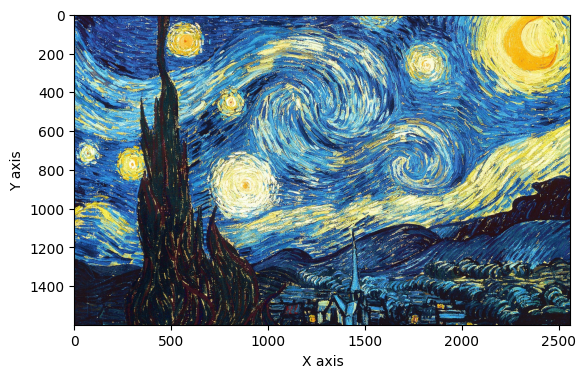

KNeighborsRegressor(n_neighbors=4, weights='distance')

In [7]:
X, Y = read_style_image(os.path.join(path, 'style.jpg')) # 建立映射

# weights='distance'表示邻居的权重与其到样本的距离成反比
knn = KNeighborsRegressor(n_neighbors=4, weights='distance')
knn.fit(X, Y)

In [8]:
def rebuild(img, size=block_size):
    # 打印内容图像
    fig = plt.figure()
    plt.imshow(img)
    plt.xlabel('X axis')
    plt.ylabel('Y axis')
    plt.show()

    # 将内容图像转为LAB表示
    img = rgb2lab(img)
    w, h = img.shape[:2]

    # 初始化输出图像对应的矩阵
    photo = np.zeros([w, h, 3])
    # 枚举内容图像的中心点，保存所有窗口
    print('Constructing window...')
    X = []
    for x in range(size, w - size):
        for y in range(size, h - size):
            # 得到中心点对应的窗口
            window = img[x - size: x + size + 1, \
                y - size: y + size + 1, 0].flatten()
            X.append(window)
    X = np.array(X)

    # 用KNN回归器预测颜色
    print('Predicting...')
    pred_ab = knn.predict(X).reshape(w - 2 * size, h - 2 * size, -1)
    # 设置输出图像
    photo[:, :, 0] = img[:, :, 0]
    photo[size: w - size, size: h - size, 1:] = pred_ab

    # 由于最外面size层无法构造窗口，简单起见，我们直接把这些像素裁剪掉
    photo = photo[size: w - size, size: h - size, :]
    return photo

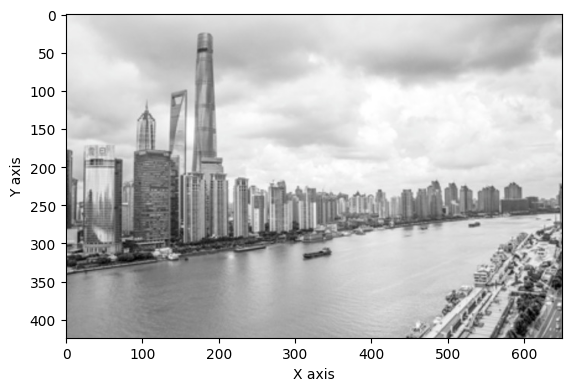

Constructing window...
Predicting...


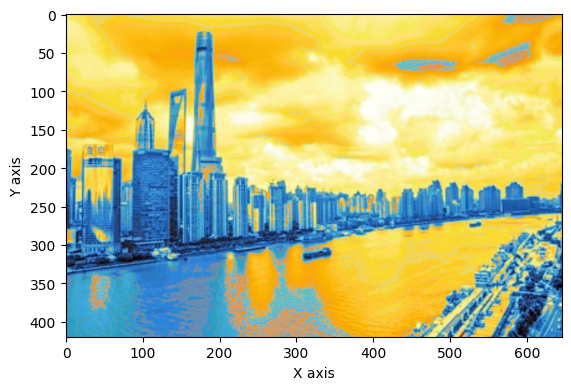

In [9]:
content = io.imread(os.path.join(path, 'input.jpg'))
new_photo = rebuild(content)
# 为了展示图像，我们将其再转换为RGB表示
new_photo = lab2rgb(new_photo)

fig = plt.figure()
plt.imshow(new_photo)
plt.xlabel('X axis')
plt.ylabel('Y axis')
plt.show()

## 习题5
思考一下自己在生活、工作中，是否也使过 KNN 算法？自己为什么使用 KNN 算法来处理碰到的问题？

**解答**

&emsp;&emsp;使用KNN算法处理问题的核心原因在于其独特的灵活性和直观性。作为一种基于实例的学习方法，KNN无需复杂的模型训练过程，直接通过计算样本间的相似性进行预测，这种特性使其在小规模数据或快速验证场景中尤为高效。例如，在电商初期构建推荐系统时，仅需存储用户行为数据并实时计算相似用户偏好，即可快速生成推荐结果，无需等待模型训练时间。同时，KNN的决策逻辑透明易懂，比如在金融风控中解释“某交易因与5笔历史异常交易特征相似而被拦截”，这种基于相似案例的推理方式更容易获得业务方的信任，特别适用于医疗诊断、信用评估等需要高解释性的领域。其灵活性还体现在对分类与回归任务的双重支持上，通过调整K值、距离度量（如欧氏距离捕捉全局关系、曼哈顿距离适应网格数据）以及加权投票规则，既能处理离散标签的客户分群问题，也能预测连续值的房屋售价趋势。  
&emsp;&emsp;然而，KNN的应用需结合具体场景权衡利弊。在动态数据环境中，如实时用户行为分析或流式数据处理，KNN的优势尤为突出——新增数据可即时参与计算，避免传统模型因数据分布变化导致的频繁重训练。但面对大规模高维数据时，其计算效率会显著下降，此时需借助KD树索引优化或特征降维技术提升性能。例如，在图像风格迁移中，若直接使用原始像素等高维特征，不仅计算耗时，还容易因维度灾难导致匹配偏差，此时引入主成分分析（PCA）压缩特征维度成为必要策略。此外，KNN对噪声和类别不平衡较为敏感，需通过距离加权投票、自适应K值选择或数据重采样等手段优化结果。总体而言，KNN如同一种“数据驱动的经验推理工具”，在数据量适中、解释性优先、特征空间稳定的场景中展现出独特价值，但在计算资源受限或数据复杂性极高的任务中，仍需与深度学习等模型互补使用。

## 习题6
在本书的在线版本里，我们在 vangogh 文件夹下还提供了许多其他的梵高画作。如果我们将所有画作中的窗口都提取出来，用 KNN 去匹配，最后上色的结果会是什么样？下面提供了相关代码，观察结果，并思考产生该结果的原因。从中可以发现，当使用 KNN 解决问题时，需要注意什么？

```python
# 创建由多张图像构成的数据集，num表示图像数量
# 返回的X、Y的含义与函数read_style_image相同
def create_dataset(data_dir='vangogh', num=10):
    # 初始化函数输出
    X = []
    Y = []
    # 读取图像
    files = np.sort(os.listdir(os.path.join(path, data_dir)))
    num = min(num, len(files))
    for file in files[:num]:
        print('reading', file)
        X0, Y0 = read_style_image(os.path.join(path, data_dir, file))
        X.extend(X0)
        Y.extend(Y0)
    return X, Y

X, Y = create_dataset()
knn = KNeighborsRegressor(n_neighbors=4, weights='distance')
knn.fit(X, Y)

content = io.imread(os.path.join(path, 'input.jpg'))
new_photo = rebuild(content)
new_photo = lab2rgb(new_photo)

fig = plt.figure()
plt.imshow(new_photo)
plt.xlabel('X axis')
plt.ylabel('Y axis')
plt.show()
```

**解答**

&emsp;&emsp;在本书的在线版本中，我们在 vangogh 文件夹下提供了许多梵高的画作。如果我们从中提取所有画作中的窗口部分，并使用 KNN 算法进行匹配和风格迁移，最终的上色结果会呈现以**黄色**为主的色调。  
  
&emsp;&emsp;这是因为 KNN 算法通过计算像素点之间的相似性，识别出图像中大块像素的主色调为黄色。由于梵高作品中黄色的使用频率较高，算法在遍历图像后，KNN算法在匹配过程中会优先选择黄色像素作为参考，从而使得最终的上色结果以黄色为主色调。最终，基于算法的风格化处理，图像的主色调从灰色转变为黄色。  
  
&emsp;&emsp;在使用KNN算法时，需重点关注数据预处理（如标准化以消除量纲差异）、合理选择K值（通过交叉验证平衡过拟合与欠拟合）、优化距离度量（高维数据优先曼哈顿距离或余弦相似度）及处理类别不平衡（如加权投票），同时警惕维数灾难带来的距离失效问题；对于大规模数据，需采用KD树或近似算法提升计算效率，并确保内存足够存储全部训练集，避免因数据动态更新导致的实时性瓶颈。此外，噪声数据需通过调整K值或引入距离权重过滤干扰。

reading 00001.jpg


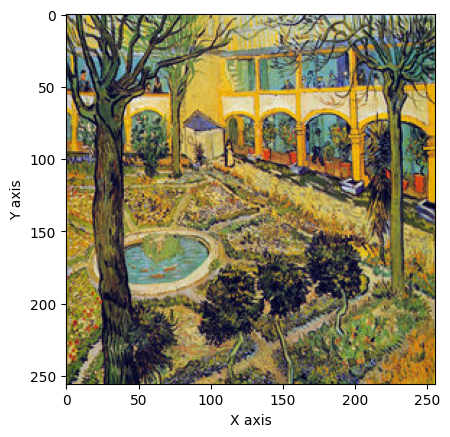

reading 00002.jpg


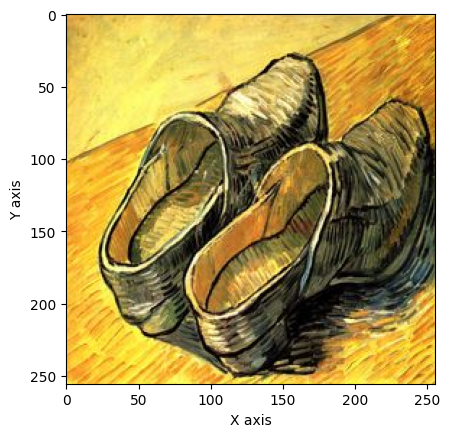

reading 00003.jpg


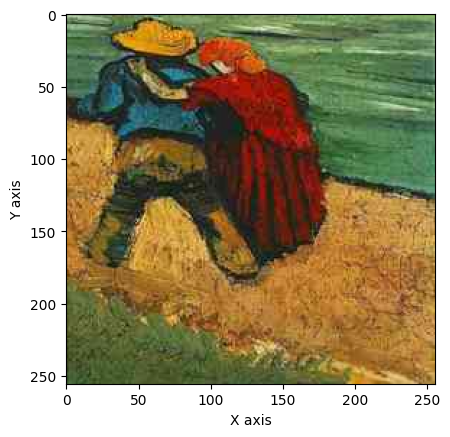

reading 00004.jpg


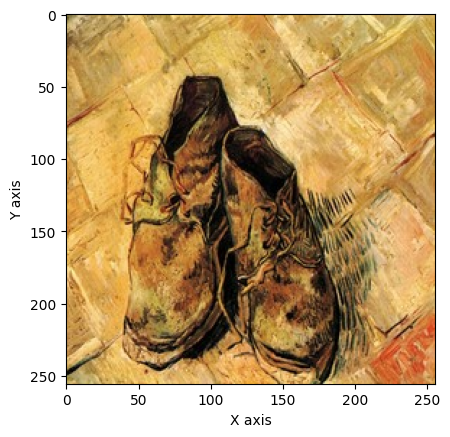

reading 00005.jpg


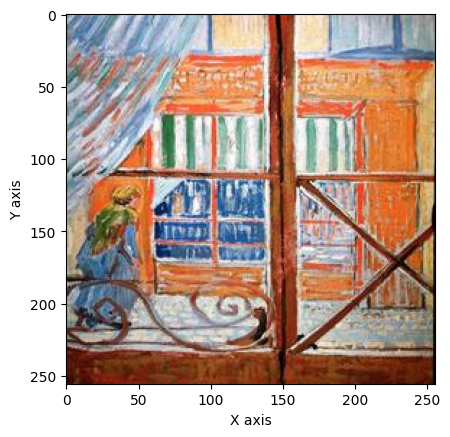

reading 00006.jpg


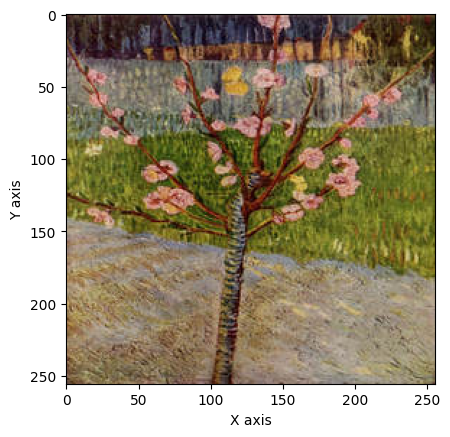

reading 00007.jpg


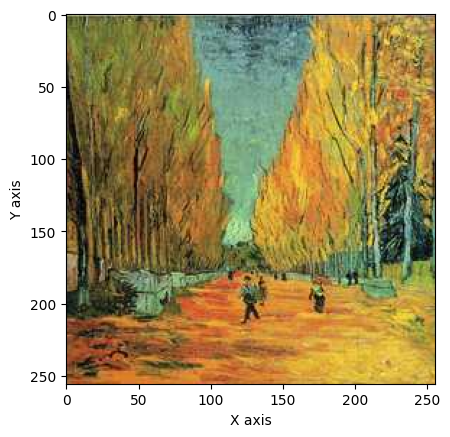

reading 00008.jpg


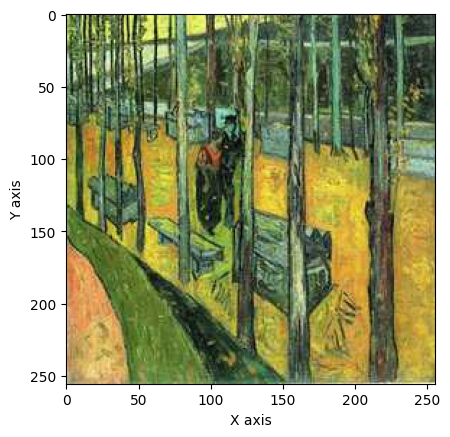

reading 00009.jpg


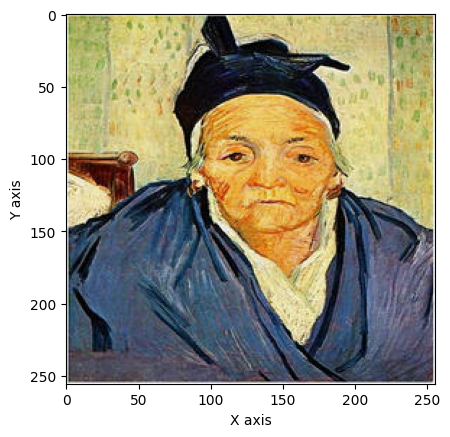

reading 00010.jpg


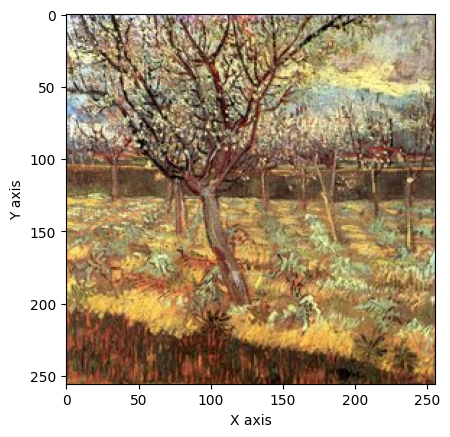

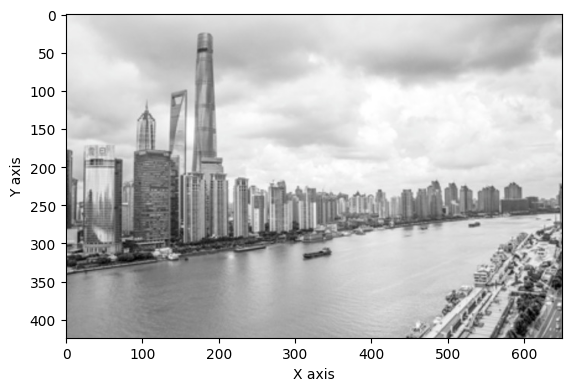

Constructing window...
Predicting...


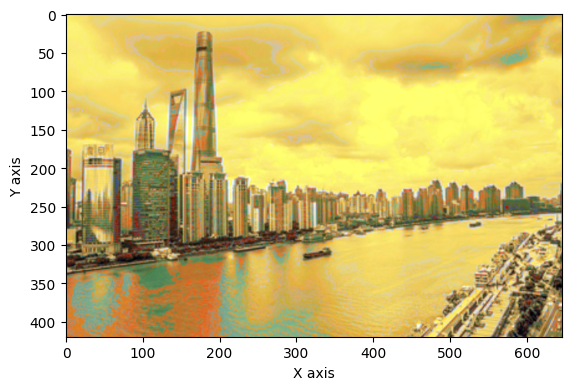

In [10]:
# 创建由多张图像构成的数据集，num表示图像数量
# 返回的X、Y的含义与函数read_style_image相同
def create_dataset(data_dir='vangogh', num=10):
    # 初始化函数输出
    X = []
    Y = []
    # 读取图像
    files = np.sort(os.listdir(os.path.join(path, data_dir)))
    num = min(num, len(files))
    for file in files[:num]:
        print('reading', file)
        X0, Y0 = read_style_image(os.path.join(path, data_dir, file))
        X.extend(X0)
        Y.extend(Y0)
    return X, Y

X, Y = create_dataset()
knn = KNeighborsRegressor(n_neighbors=4, weights='distance')
knn.fit(X, Y)

content = io.imread(os.path.join(path, 'input.jpg'))
new_photo = rebuild(content)
new_photo = lab2rgb(new_photo)

fig = plt.figure()
plt.imshow(new_photo)
plt.xlabel('X axis')
plt.ylabel('Y axis')
plt.show()
